Mounted at /content/drive
Using device: cuda
Epoch 1/10
Average training loss: 0.6933358288129171
Running Validation...
Validation Accuracy: 0.5020467252396166
Validation Loss: 0.6938071889808765
Epoch 2/10
Average training loss: 0.6933156044324239
Running Validation...
Validation Accuracy: 0.49450878594249204
Validation Loss: 0.6931457860401263
Epoch 3/10
Average training loss: 0.6932639485359192
Running Validation...
Validation Accuracy: 0.505491214057508
Validation Loss: 0.6931513975413082
Epoch 4/10
Average training loss: 0.6932392858187357
Running Validation...
Validation Accuracy: 0.501797124600639
Validation Loss: 0.6931441377717465
Epoch 5/10
Average training loss: 0.6932009642918905
Running Validation...
Validation Accuracy: 0.49795327476038337
Validation Loss: 0.6932135192921367
Epoch 6/10
Average training loss: 0.693284081363678
Running Validation...
Validation Accuracy: 0.5020467252396166
Validation Loss: 0.6931484172138543
Early stopping triggered.
Training time: 31.01 sec

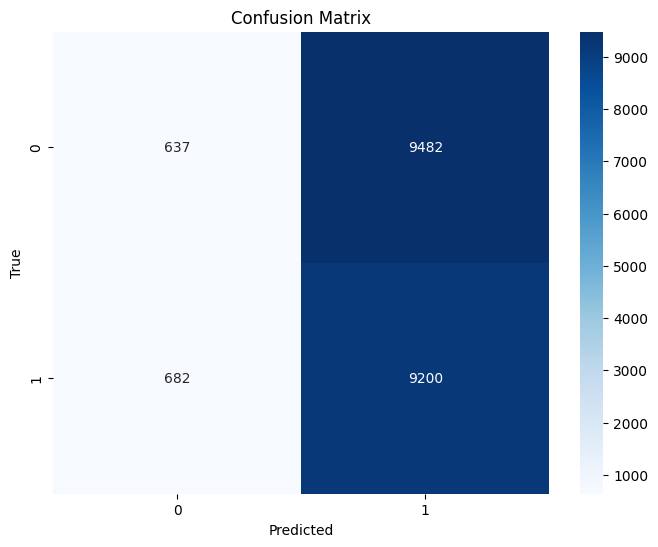

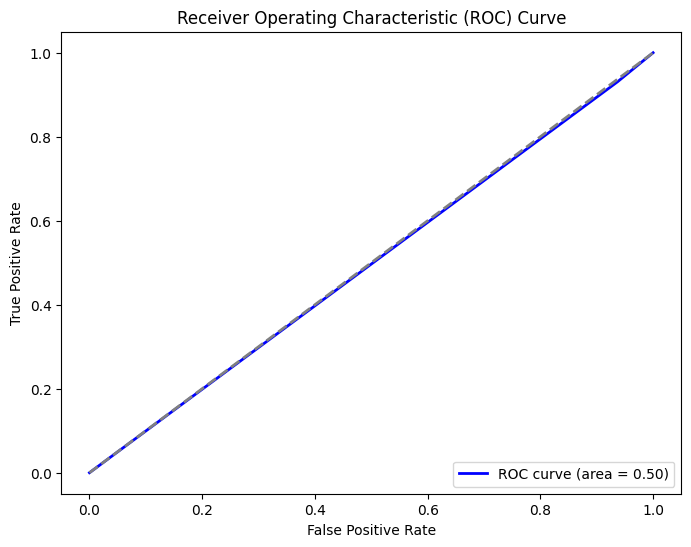

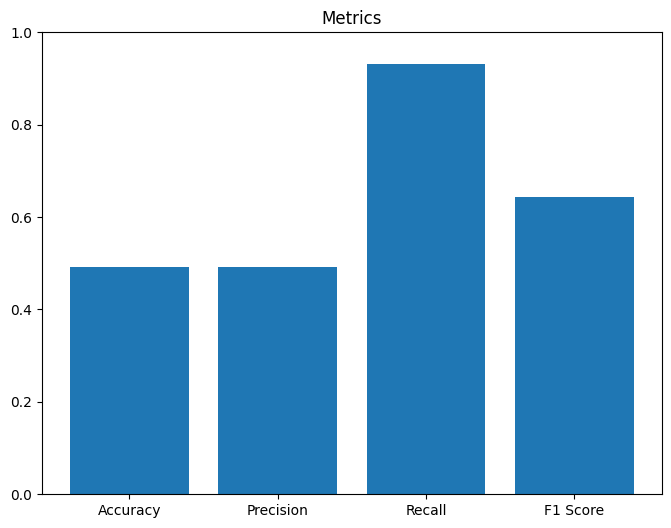

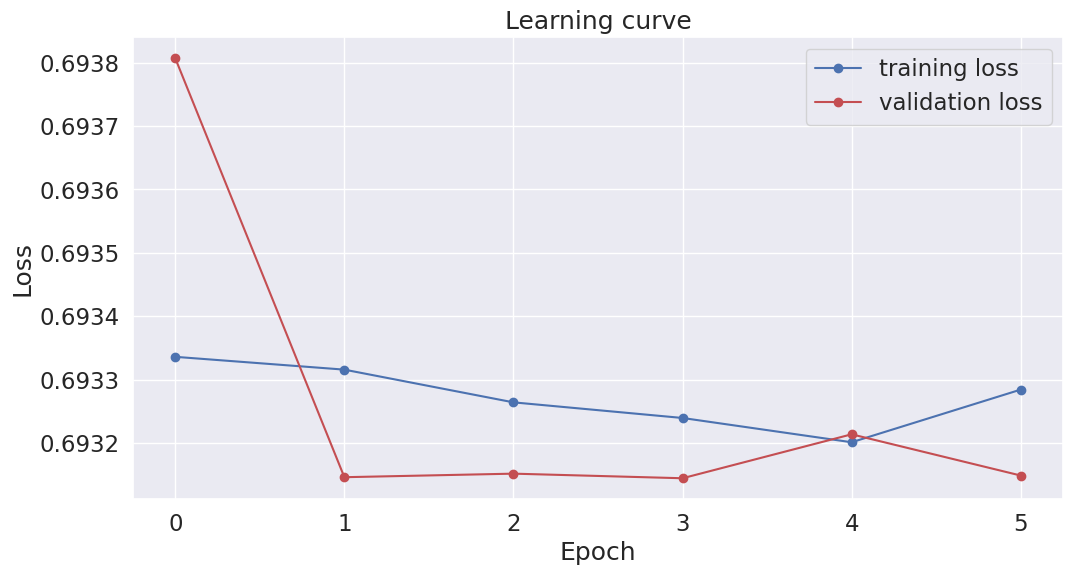

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import time

from google.colab import drive
drive.mount('/content/drive')

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Impala/attack-free-1.csv', delimiter=',')

df['arbitration_id'] = df['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['data_field'] = df['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['attack'] = 0
df = df.loc[:50000, ['arbitration_id', 'data_field', 'attack']]

dg = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Impala/standstill-1.csv', delimiter=',')

dg['arbitration_id'] = dg['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dg['data_field'] = dg['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dg['attack'] = 1
dg = dg.loc[:50000, ['arbitration_id', 'data_field', 'attack']]

# Feature and label extraction
data = pd.concat([df, dg])
data = shuffle(data)

X = data[['arbitration_id', 'data_field']]
y = data['attack']

# Convert features to float
X = X.astype(float)

# Scaling the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape the features for LSTM
X_scaled = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split the data into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Convert to PyTorch tensors
X_train, y_train = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.long)
X_val, y_val = torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.long)
X_test, y_test = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.long)

# Create DataLoader
batch_size = 32

train_data = TensorDataset(X_train, y_train)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(X_val, y_val)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

test_data = TensorDataset(X_test, y_test)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

# Define LSTM model
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=n_layers, bidirectional=bidirectional, dropout=(dropout if n_layers > 1 else 0), batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h0, c0 = self.init_hidden(x.size(0))
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(self.dropout(out[:, -1, :]))
        return out

    def init_hidden(self, batch_size):
        h0 = torch.zeros(self.lstm.num_layers * 2 if self.lstm.bidirectional else self.lstm.num_layers, batch_size, self.lstm.hidden_size).to(device)
        c0 = torch.zeros(self.lstm.num_layers * 2 if self.lstm.bidirectional else self.lstm.num_layers, batch_size, self.lstm.hidden_size).to(device)
        return h0, c0

# Set the best hyperparameters
best_params = {
    'hidden_dim': 128,
    'n_layers': 1,
    'bidirectional': False,
    'dropout': 0.2,
    'lr': 0.001
}

model = LSTMClassifier(
    input_dim=X_train.shape[2],
    hidden_dim=best_params['hidden_dim'],
    output_dim=2,
    n_layers=best_params['n_layers'],
    bidirectional=best_params['bidirectional'],
    dropout=best_params['dropout']
)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

patience = 2
early_stopping_counter = 0
best_validation_loss = float('inf')
loss_values, validation_loss_values = [], []

training_start_time = time.time()

for epoch_i in range(0, 10):
    print(f"Epoch {epoch_i + 1}/10")
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_dataloader):
        b_input, b_labels = batch
        b_input, b_labels = b_input.to(device), b_labels.to(device)

        model.zero_grad()
        outputs = model(b_input)
        loss = criterion(outputs, b_labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    avg_train_loss = total_loss / len(train_dataloader)
    loss_values.append(avg_train_loss)
    print(f'Average training loss: {avg_train_loss}')

    print('Running Validation...')
    model.eval()
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0

    for batch in val_dataloader:
        b_input, b_labels = batch
        b_input, b_labels = b_input.to(device), b_labels.to(device)

        with torch.no_grad():
            outputs = model(b_input)
        loss = criterion(outputs, b_labels)
        eval_loss += loss.item()
        preds_flat = np.argmax(outputs.detach().cpu().numpy(), axis=1).flatten()
        labels_flat = b_labels.cpu().numpy().flatten()
        eval_accuracy += np.sum(preds_flat == labels_flat) / len(labels_flat)
        nb_eval_steps += 1

    avg_val_accuracy = eval_accuracy / nb_eval_steps
    avg_val_loss = eval_loss / nb_eval_steps
    validation_loss_values.append(avg_val_loss)
    print(f'Validation Accuracy: {avg_val_accuracy}')
    print(f'Validation Loss: {avg_val_loss}')

    if avg_val_loss < best_validation_loss:
        best_validation_loss = avg_val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_lstm_model.pt')
    else:
        early_stopping_counter += 1

    if early_stopping_counter >= patience:
        print('Early stopping triggered.')
        break

training_end_time = time.time()
training_time = training_end_time - training_start_time
print(f'Training time: {training_time:.2f} seconds')

print(f"Best Validation Accuracy: {avg_val_accuracy:.4f}")

# Load the best model
model.load_state_dict(torch.load('best_lstm_model.pt'))

# Evaluate on the test set
model.eval()
predictions, true_labels = [], []
test_start_time = time.time()

for batch in test_dataloader:
    b_input, b_labels = batch
    b_input, b_labels = b_input.to(device), b_labels.to(device)

    with torch.no_grad():
        outputs = model(b_input)

    logits = outputs.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()
    predictions.extend(np.argmax(logits, axis=1).flatten())
    true_labels.extend(label_ids.flatten())

test_end_time = time.time()
test_time = test_end_time - test_start_time

print(f"Test complete! Total prediction time: {test_time:.2f} seconds")

# Classification report
print(classification_report(true_labels, predictions, digits=4))

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Bar plot for metrics
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
plt.figure(figsize=(8, 6))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.title('Metrics')
plt.show()

# Plot the learning curve
sns.set(style='darkgrid')
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12, 6)
plt.plot(loss_values, 'b-o', label="training loss")
plt.plot(validation_loss_values, 'r-o', label="validation loss")
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
